In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/ptbxl_metadata_prepared.csv", index_col="ecg_id")
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

with h5py.File("../data/processed/raw_signals_100hz.h5", "r") as h5f:  # Lazy Loading
    patient_idx = 0
    single_signal = h5f["signals"][patient_idx]
    single_labels = h5f["labels"][patient_idx]
    patient_ecg_id = h5f["ecg_id"][patient_idx]

print(f"Wybrane badanie ID: {patient_ecg_id}")
print(f"Kształt sygnału (próbki x odprowadzenia): {single_signal.shape}")
print(f"Wektor etykiet (NORM, MI, STTC, CD, HYP): {single_labels}")

Wybrane badanie ID: 1
Kształt sygnału (próbki x odprowadzenia): (1000, 12)
Wektor etykiet (NORM, MI, STTC, CD, HYP): [1 0 0 0 0]


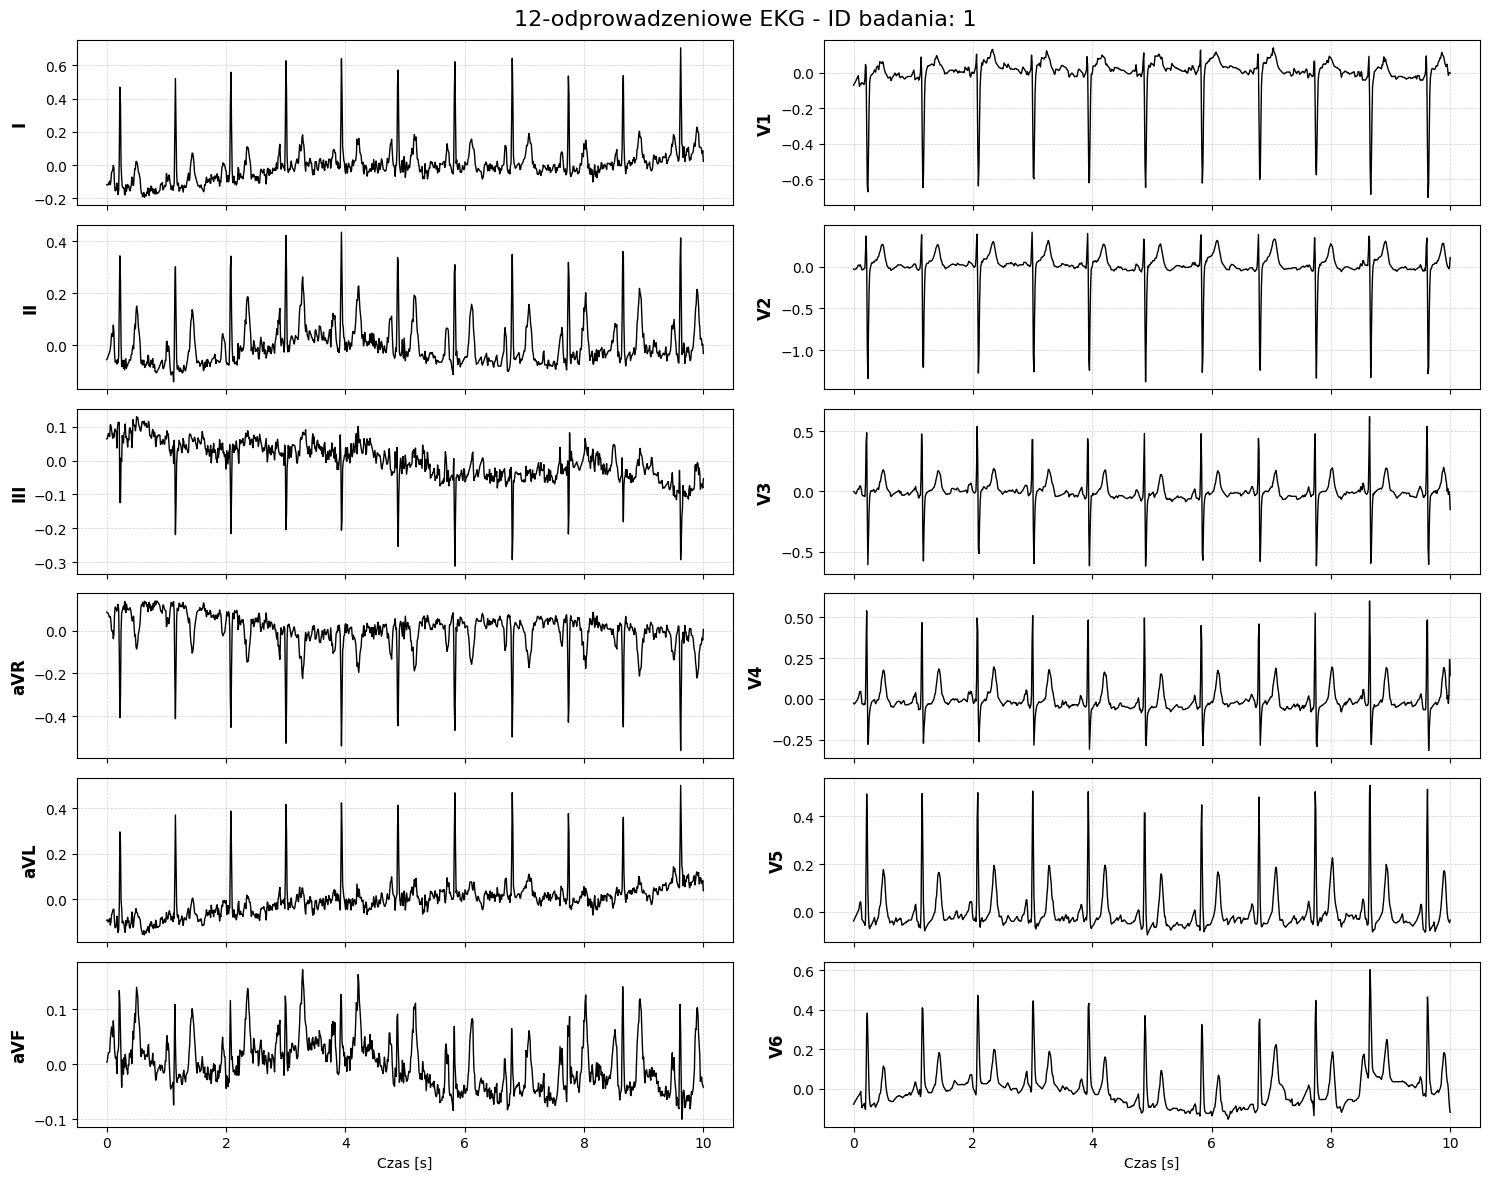

In [3]:
time_axis = np.linspace(0, 10, 1000)

fig, axes = plt.subplots(6, 2, figsize=(15, 12), sharex=True)
fig.suptitle(f"12-odprowadzeniowe EKG - ID badania: {patient_ecg_id}", fontsize=16)

for i in range(12):
    row = i % 6
    col = i // 6
    ax = axes[row, col]

    ax.plot(time_axis, single_signal[:, i], color='black', linewidth=1)
    ax.set_ylabel(lead_names[i], fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)

    if row == 5:
        ax.set_xlabel("Czas [s]")

plt.tight_layout()
plt.show()